# ANÁLISE EXPLORATÓRIA DE DADOS (EDA) - Trabalho 1 — Dataset tips (gorjetas)


In [2]:
# Questão 1
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="darkgrid") #darkgrid
plt.rcParams["figure.figsize"] = (10, 6)

df = sns.load_dataset("tips")
df.head()

print(f"Número de linhas: {df.shape[0]}")
print(f"Número de colunas: {df.shape[1]}")

df.info()

Número de linhas: 244
Número de colunas: 7
<class 'pandas.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   total_bill  244 non-null    float64 
 1   tip         244 non-null    float64 
 2   sex         244 non-null    category
 3   smoker      244 non-null    category
 4   day         244 non-null    category
 5   time        244 non-null    category
 6   size        244 non-null    int64   
dtypes: category(4), float64(2), int64(1)
memory usage: 7.4 KB


In [4]:
# Questão 2
df.describe()

df.isnull().sum()

total_bill    0
tip           0
sex           0
smoker        0
day           0
time          0
size          0
dtype: int64

**Questão 2**

- A conta (`total_bill`) tem média de **19,79** e desvio-padrão de **8,90**. Isso mostra que a conta típica gira em torno de R$ 20, mas com uma variação considerável ao redor desse valor — existem tanto contas baixas quanto contas bem mais altas.
- A gorjeta (`tip`) tem média de **3,00** e desvio-padrão de **1,38**. O desvio-padrão é relativamente grande perto da média, o que indica que o valor da gorjeta não segue um padrão fixo entre os clientes.
- No geral, tanto a conta quanto a gorjeta apresentam variação alta em relação à sua média, o que sugere que os clientes têm hábitos de consumo e de gorjeta bastante diferentes entre si.

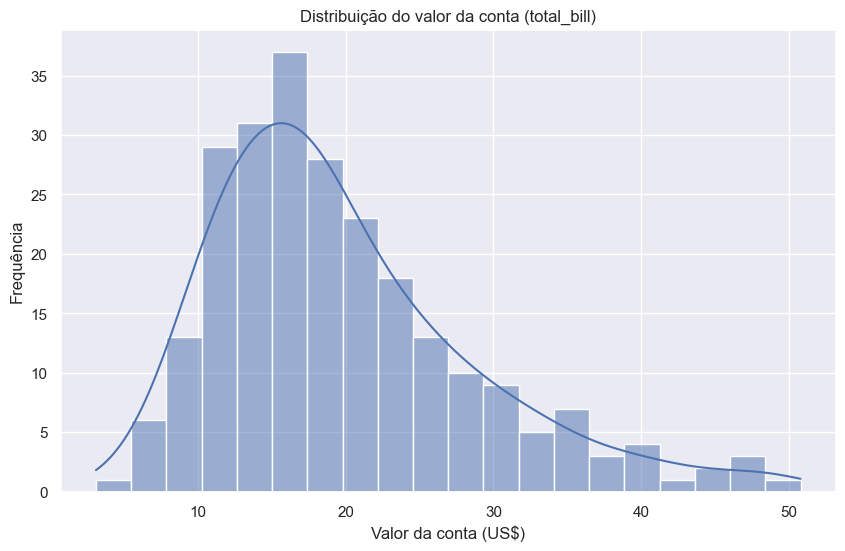

In [5]:
# Questão 3
plt.figure()
sns.histplot(data=df, x="total_bill", kde=True, bins=20)
plt.title("Distribuição do valor da conta (total_bill)")
plt.xlabel("Valor da conta (US$)")
plt.ylabel("Frequência")
plt.show()

**Questão 3**

- A distribuição é assimétrica, com uma cauda voltada para a direita: a maior parte das contas tem valor baixo ou médio, mas algumas contas de valor bem mais alto se estendem para a direita do gráfico, alongando essa cauda.
- A maior concentração de contas está na faixa entre **US$ 10 e US$ 20**, onde as barras do histograma são mais altas.
- Essa assimetria acontece porque a maioria dos clientes faz pedidos de valor moderado, enquanto uma parcela menor — geralmente grupos maiores ou pedidos mais completos — gera contas bem mais caras, o que puxa a média para um valor acima da concentração principal dos dados.

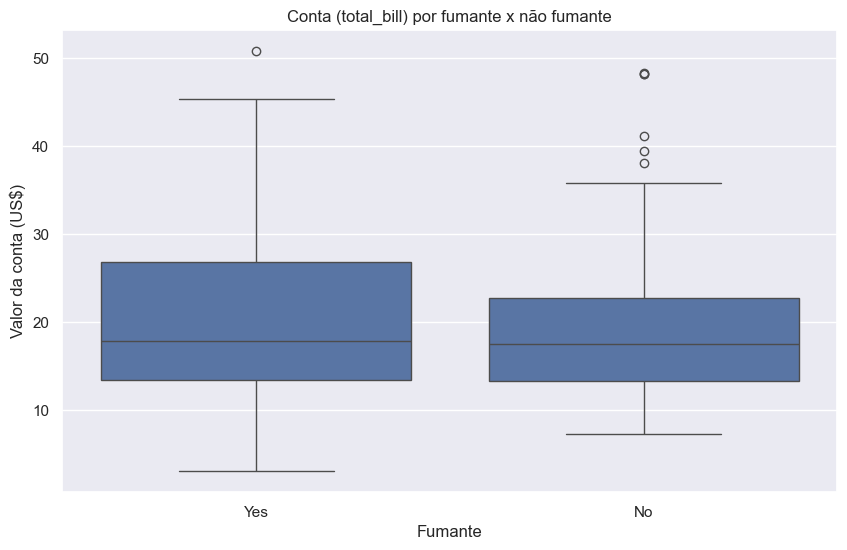

smoker
Yes    20.756344
No     19.188278
Name: total_bill, dtype: float64


In [6]:
# Questão 4
plt.figure()
sns.boxplot(data=df, x="smoker", y="total_bill")
plt.title("Conta (total_bill) por fumante x não fumante")
plt.xlabel("Fumante")
plt.ylabel("Valor da conta (US$)")
plt.show()

media_por_grupo = df.groupby("smoker")["total_bill"].mean()
print(media_por_grupo)

**Questão 4**

- Quem fuma gasta um pouco mais em média do que quem não fuma.
- Mas essa diferença é pequena, não chega a ser expressiva. As duas médias ficam próximas, e o boxplot mostra que os dois grupos têm uma faixa de valores bem parecida.
- Ou seja, fumar ou não fumar não parece ser um fator que muda muito o valor da conta.

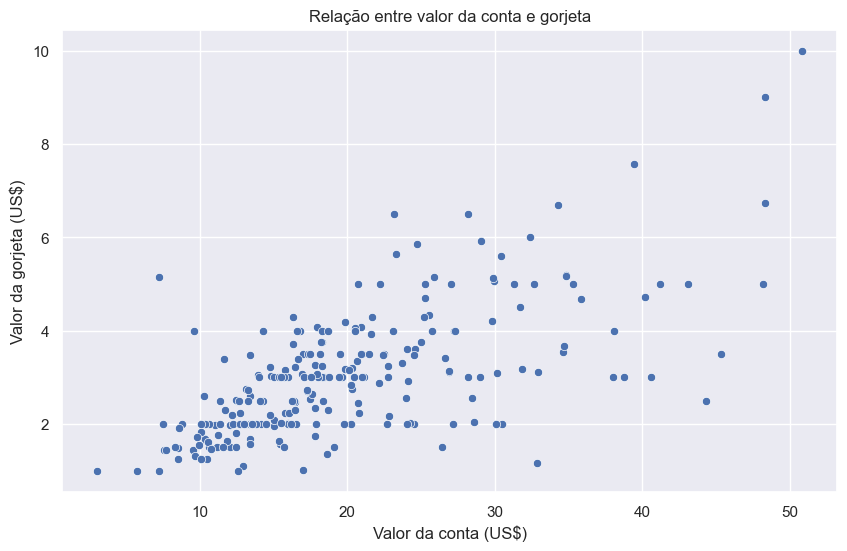

Coeficiente de correlação de Pearson: 0.676


In [7]:
# Questão 5

plt.figure()

sns.scatterplot(data=df, x="total_bill", y="tip")

plt.title("Relação entre valor da conta e gorjeta")
plt.xlabel("Valor da conta (US$)")
plt.ylabel("Valor da gorjeta (US$)")

plt.show()

correlacao = df["total_bill"].corr(df["tip"])

print(f"Coeficiente de correlação de Pearson: {correlacao:.3f}")

**Questão 5**

- O gráfico de dispersão mostra uma relação positiva entre o valor da conta (total_bill) e o valor da gorjeta (tip). De modo geral, à medida que o valor da conta aumenta, o valor da gorjeta também tende a aumentar.

- O coeficiente de correlação de Pearson encontrado foi de aproximadamente 0,676, indicando uma correlação linear positiva de magnitude moderada. Esse resultado significa que existe uma tendência de contas maiores estarem associadas a gorjetas maiores, embora essa relação não seja perfeita, pois os pontos apresentam dispersão considerável no gráfico.

- Na prática, isso indica que o valor da conta é um fator relacionado ao valor da gorjeta: clientes que possuem contas mais altas tendem, em média, a deixar gorjetas maiores. Entretanto, o valor da conta não determina sozinho o valor da gorjeta, já que outros fatores podem influenciar a decisão do cliente.

- Portanto, a relação entre total_bill e tip pode ser considerada positiva e moderada, demonstrando uma associação relevante entre as duas variáveis, mas sem indicar uma relação perfeitamente proporcional.

Gorjeta média por dia:
day
Thur    2.771452
Fri     2.734737
Sat     2.993103
Sun     3.255132
Name: tip, dtype: float64

Gorjeta média por turno:
time
Lunch     2.728088
Dinner    3.102670
Name: tip, dtype: float64


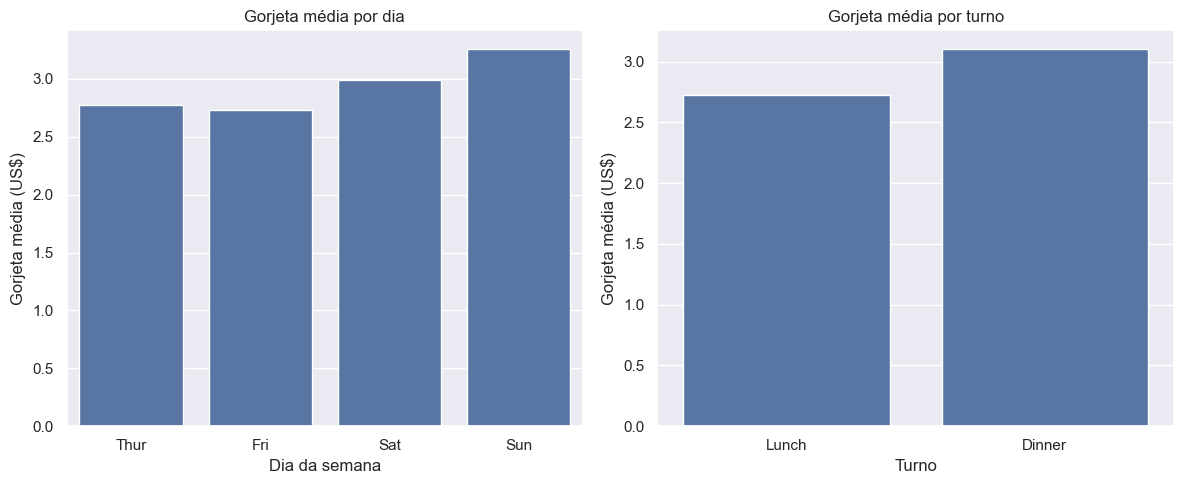

In [10]:
# Questão 6

# Média das gorjetas por dia da semana
media_por_dia = df.groupby("day")["tip"].mean()

print("Gorjeta média por dia:")
print(media_por_dia)

# Média das gorjetas por turno
media_por_turno = df.groupby("time")["tip"].mean()

print("\nGorjeta média por turno:")
print(media_por_turno)


# Gráfico de barras
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.barplot(x=media_por_dia.index, y=media_por_dia.values, ax=axes[0])
axes[0].set_title("Gorjeta média por dia")
axes[0].set_xlabel("Dia da semana")
axes[0].set_ylabel("Gorjeta média (US$)")

sns.barplot(x=media_por_turno.index, y=media_por_turno.values, ax=axes[1])
axes[1].set_title("Gorjeta média por turno")
axes[1].set_xlabel("Turno")
axes[1].set_ylabel("Gorjeta média (US$)")

plt.tight_layout()
plt.show()

**Questão 6**

As maiores gorjetas médias foram observadas no **domingo**, com aproximadamente **US$ 3,26**, e no período do **jantar**, com aproximadamente **US$ 3,10**.

Ao comparar os dias da semana, percebe-se que o domingo apresenta a maior média de gorjetas, seguido pelo sábado, enquanto quinta-feira e sexta-feira apresentam valores menores. Em relação aos turnos, o jantar possui uma média de gorjetas superior à do almoço.

Dessa forma, os dados indicam que, nesta amostra, as gorjetas tendem a ser maiores **aos domingos e no período do jantar**. Essa conclusão é baseada na comparação das médias observadas no conjunto de dados.


Correlação entre número de pessoas e conta: 0.598
Correlação entre número de pessoas e gorjeta: 0.489


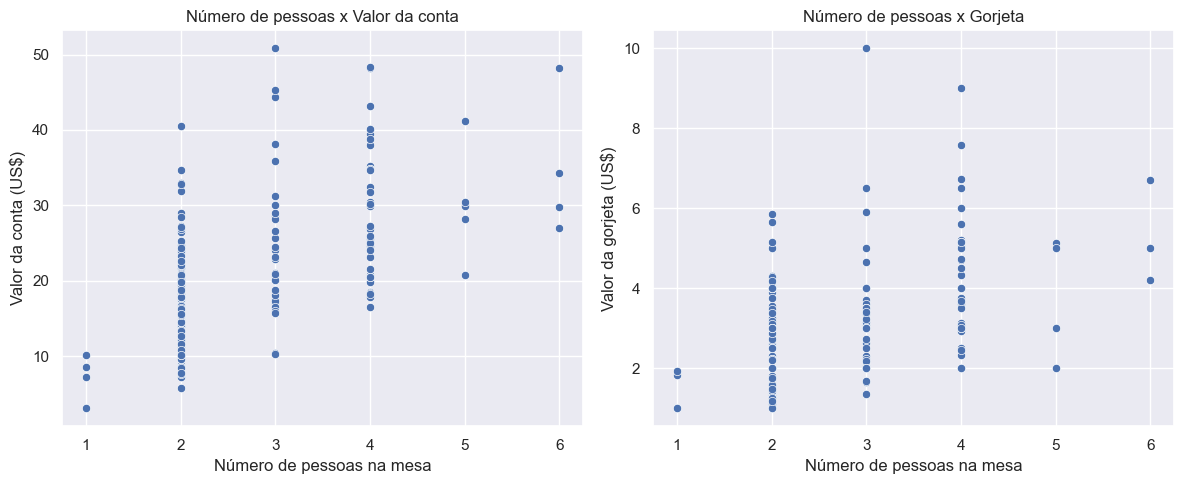

In [13]:
# Questão 7

# Correlação de Pearson
cor_size_bill = df["size"].corr(df["total_bill"])
cor_size_tip = df["size"].corr(df["tip"])

print(f"Correlação entre número de pessoas e conta: {cor_size_bill:.3f}")
print(f"Correlação entre número de pessoas e gorjeta: {cor_size_tip:.3f}")


# Gráficos de dispersão
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.scatterplot(data=df, x="size", y="total_bill", ax=axes[0])
axes[0].set_title("Número de pessoas x Valor da conta")
axes[0].set_xlabel("Número de pessoas na mesa")
axes[0].set_ylabel("Valor da conta (US$)")

sns.scatterplot(data=df, x="size", y="tip", ax=axes[1])
axes[1].set_title("Número de pessoas x Gorjeta")
axes[1].set_xlabel("Número de pessoas na mesa")
axes[1].set_ylabel("Valor da gorjeta (US$)")

plt.tight_layout()
plt.show()

**Questão 7**

A análise da relação entre o número de pessoas na mesa (`size`), o valor da conta (`total_bill`) e o valor da gorjeta (`tip`) foi realizada por meio do coeficiente de correlação de Pearson e de gráficos de dispersão.

A correlação entre o número de pessoas na mesa e o valor da conta foi de aproximadamente **0,598**, indicando uma **relação positiva moderada**. Isso significa que mesas com mais pessoas tendem a apresentar valores de conta maiores.

Entre o número de pessoas e a gorjeta, a correlação foi de aproximadamente **0,489**, também indicando uma relação positiva, porém moderada. Portanto, mesas maiores tendem a apresentar gorjetas maiores, mas essa relação é menos intensa do que a observada entre o tamanho da mesa e o valor da conta.

Dessa forma, os dados **não indicam que as gorjetas sejam proporcionais ao número de pessoas na mesa**. Existe uma tendência de aumento da gorjeta conforme o tamanho da mesa aumenta, mas o comportamento não é perfeitamente proporcional, pois outros fatores também podem influenciar o valor deixado como gorjeta.
